# Depersin and Barthelemy, 2018

In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import to_hex
from pathlib import Path

In [84]:
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
})

## Data

In [85]:
df_raw = pd.read_excel("data/complete-data-2025-umr-by-tti.xlsx", header=None, skiprows=5)

df_raw = df_raw.iloc[:, [1, 4, 5, 7, 8, 9, 21]].copy()
df_raw.columns = ["city", "year", "pop_k", "commuters_k", "freeway_DVMT_k", "arterial_DVMT_k", "delay_kh"]
df_raw = df_raw.dropna(subset=["city", "year", "commuters_k", "delay_kh"])
df_raw["year"] = pd.to_numeric(df_raw["year"], errors="coerce").astype("Int64")
df_raw = df_raw.dropna(subset=["year"]).copy()
df_raw["year"] = df_raw["year"].astype(int)

In [86]:
# Original paper panel: cities with continuous data 1982â€“2014
core_cities = sorted(
    c for c in df_raw.loc[df_raw["year"] == 1982, "city"].unique()
    if set(range(1982, 2015)).issubset(set(df_raw.loc[df_raw["city"] == c, "year"]))
)
df = df_raw[df_raw["city"].isin(core_cities) &
         (df_raw["year"] >= 1982) & (df_raw["year"] <= 2014)].copy()

In [87]:
# Convert to absolute units (paper uses df_raw P, Î´Ï„ â€” not thousands)
df["P"] = df["commuters_k"] * 1_000.0   # auto commuters
df["delay"] = df["delay_kh"] * 1_000.0  # person-hours
# total daily VMT (vehicle-miles), used for L_tot in Birmingham analysis
df["Ltot"] = (df["freeway_DVMT_k"].fillna(0) +
              df["arterial_DVMT_k"].fillna(0)) * 1_000.0
df = df.sort_values(["city", "year"]).reset_index(drop=True)

df.head()

,city,year,pop_k,commuters_k,freeway_DVMT_k,arterial_DVMT_k,delay_kh,P,delay,Ltot
0,Akron OH,1982,515,205,2745.0,2120.0,1751,205000.0,1751000.0,4865000.0
1,Akron OH,1983,515,208,3160.0,2380.0,2037,208000.0,2037000.0,5540000.0
2,Akron OH,1984,515,209,3290.0,2555.0,2604,209000.0,2604000.0,5845000.0
3,Akron OH,1985,515,211,3255.0,2395.0,2689,211000.0,2689000.0,5650000.0
4,Akron OH,1986,515,212,3390.0,2715.0,2980,212000.0,2980000.0,6105000.0


## Utils

In [88]:
from sklearn.linear_model import LinearRegression

In [89]:
def ols_loglog(P, Y, n_outliers=0):
    """
    Return (slope β, intercept log a, R², SSR) for log Y = log a + β log P.

    If n_outliers > 0, fit once on all points, drop the n_outliers largest
    absolute residuals in log-space, then refit on the retained points.
    """
    x = np.log(np.asarray(P, dtype=float)).reshape(-1, 1)
    y = np.log(np.asarray(Y, dtype=float))

    n_outliers = int(max(0, n_outliers))
    if len(y) <= n_outliers + 1:
        n_outliers = max(0, len(y) - 2)

    model = LinearRegression()
    model.fit(x, y)

    if n_outliers > 0:
        resid = y - model.predict(x)
        keep = np.argsort(np.abs(resid))[: len(y) - n_outliers]
        x_fit = x[keep]
        y_fit = y[keep]
        model = LinearRegression()
        model.fit(x_fit, y_fit)
    else:
        x_fit = x
        y_fit = y

    beta = model.coef_[0]
    inter = model.intercept_
    yhat = model.predict(x_fit)
    ss_res = ((y_fit - yhat) ** 2).sum()
    ss_tot = ((y_fit - y_fit.mean()) ** 2).sum()
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return beta, inter, r2, ss_res

In [90]:
def best_piecewise(P, Y, min_seg=4, n_outliers_per_seg=0):
    """
    Two-segment OLS in log-log. Try every interior breakpoint index k with
    at least `min_seg` points on each side; choose k* minimising total SSR.
    Returns (k_star, β1, β2, log a1, log a2, P_star, ss_res_total).
    Optionally trims n_outliers_per_seg largest residual points in each segment
    before final segment refits.
    """
    x = np.log(np.asarray(P, dtype=float))
    y = np.log(np.asarray(Y, dtype=float))
    n = len(x)
    n_outliers_per_seg = int(max(0, n_outliers_per_seg))

    def fit_segment(x_seg, y_seg):
        model = LinearRegression()
        x2d = x_seg.reshape(-1, 1)
        model.fit(x2d, y_seg)

        if n_outliers_per_seg > 0 and len(y_seg) > n_outliers_per_seg + 1:
            resid = y_seg - model.predict(x2d)
            keep = np.argsort(np.abs(resid))[: len(y_seg) - n_outliers_per_seg]
            x_seg = x_seg[keep]
            y_seg = y_seg[keep]
            x2d = x_seg.reshape(-1, 1)
            model = LinearRegression()
            model.fit(x2d, y_seg)

        b = model.coef_[0]
        i = model.intercept_
        ss = ((y_seg - model.predict(x2d)) ** 2).sum()
        return b, i, ss

    best = None
    for k in range(min_seg, n - min_seg + 1):
        # Segment 1: indices [0, k); segment 2: indices [k, n)
        x1, y1 = x[:k], y[:k]
        x2, y2 = x[k:], y[k:]
        b1, i1, ss1 = fit_segment(x1, y1)
        b2, i2, ss2 = fit_segment(x2, y2)
        ss = ss1 + ss2
        if best is None or ss < best[0]:
            best = (ss, k, b1, b2, i1, i2)
    ss, k, b1, b2, i1, i2 = best
    P_star = np.exp((i2 - i1) / (b1 - b2)) if b1 != b2 else np.exp(x[k])
    return dict(k=k, beta1=b1, beta2=b2, loga1=i1, loga2=i2,
                P_star=P_star, ss_res=ss)

In [91]:
def city_panel(name):
    g = df[df["city"] == name].sort_values("year")
    return g["year"].values, g["P"].values, g["delay"].values, g["Ltot"].values

In [92]:
def find_city(substr):
    matches = [c for c in df["city"].unique() if substr.lower() in c.lower()]
    return matches[0] if matches else None

## Fig. 1

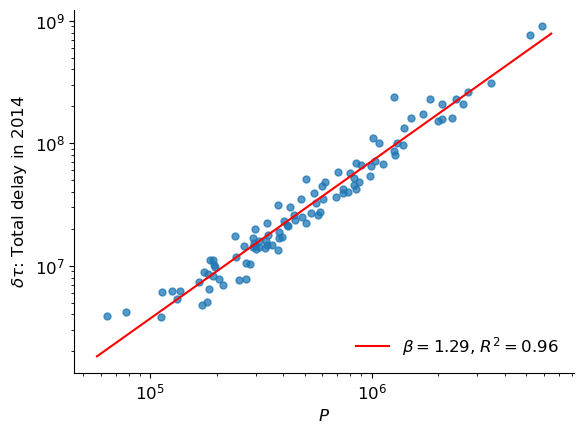

In [93]:
g14 = df[df["year"] == 2014]
P14, D14 = g14["P"].values, g14["delay"].values

beta1, loga1, r2_1, _ = ols_loglog(P14, D14)

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.loglog(P14, D14, "o", color="tab:blue", markersize=5, alpha=0.75)
xx = np.array([P14.min() * 0.9, P14.max() * 1.1])
ax.loglog(xx, np.exp(loga1) * xx ** beta1, "r-", linewidth=1.5, label=fr"$\beta = {beta1:.2f}$, $R^2 = {r2_1:.2f}$")

ax.set_xlabel(r"$P$")
ax.set_ylabel(r"$\delta\tau$: Total delay in 2014")
ax.legend(loc="lower right")

fig.tight_layout()
fig.savefig("figs/2014_deltatau_P.pdf", bbox_inches="tight", pad_inches=0)

## Fig. 2

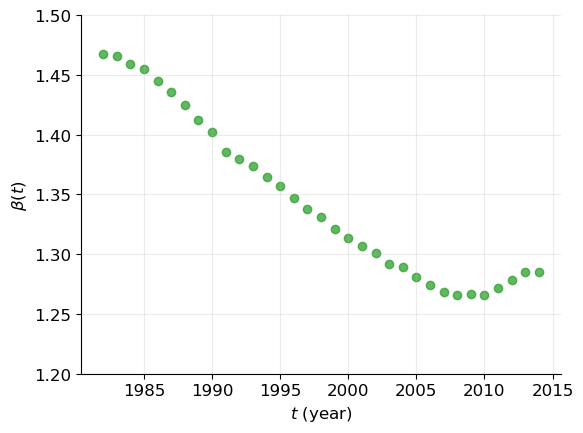

In [94]:
years = sorted(df["year"].unique())
betas_by_year = []
for t in years:
    g = df[df["year"] == t]
    b, _, _, _ = ols_loglog(g["P"].values, g["delay"].values)
    betas_by_year.append(b)
betas_by_year = np.array(betas_by_year)

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(years, betas_by_year, color="tab:green", s=36, alpha=0.75)

ax.set_ylim(1.2, 1.5)
ax.set_xlabel(r"$t$ (year)")
ax.set_ylabel(r"$\beta(t)$")
ax.grid(True, alpha=0.25)

fig.tight_layout()
fig.savefig("figs/betat_t.pdf", bbox_inches="tight", pad_inches=0)

## Fig. 3

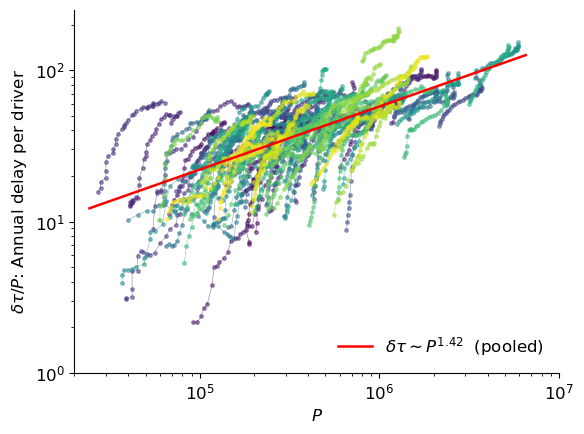

In [95]:
P_all, D_all = df["P"].values, df["delay"].values
DP_all = D_all / P_all   # delay per capita
beta_pool, loga_pool, r2_pool, _ = ols_loglog(P_all, D_all)

cities_sorted = sorted(df["city"].unique())
cmap = plt.get_cmap("viridis", len(cities_sorted))

fig, ax = plt.subplots(figsize=(6, 4.5))

xx = np.array([P_all.min() * 0.9, P_all.max() * 1.1])
ax.loglog(xx, np.exp(loga_pool) * xx ** (beta_pool - 1), "r-", lw=1.8,
          label=fr"$\delta\tau \sim P^{{{beta_pool:.2f}}}$  (pooled)", zorder=2)

for k, c in enumerate(cities_sorted):
    g = df[df["city"] == c].sort_values("year")
    ax.loglog(g["P"], g["delay"] / g["P"], "o-", color=cmap(k), markersize=2.5, lw=0.5, alpha=0.5, zorder=1)

ax.set_xlim(2e4, 1e7)
ax.set_ylim(1, 250)
ax.set_xlabel(r"$P$")
ax.set_ylabel(r"$\delta\tau / P$: Annual delay per driver")
ax.legend(loc="lower right")

fig.tight_layout()
fig.savefig("figs/deltatau_P_P.pdf", bbox_inches="tight", pad_inches=0)

## Fig. 4

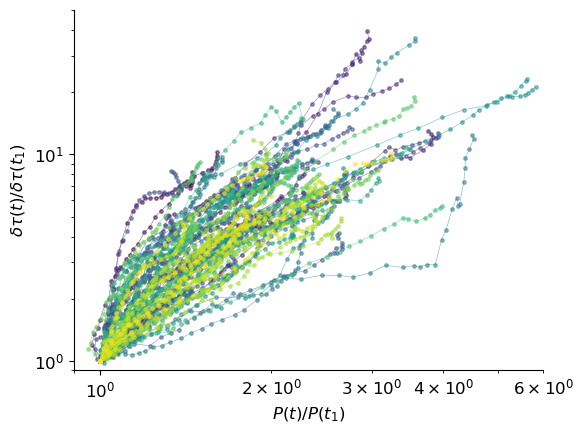

In [96]:
fig, ax = plt.subplots(figsize=(6, 4.5))
for k, c in enumerate(cities_sorted):
    _, P, D, _ = city_panel(c)
    if len(P) >= 2:
        ax.loglog(P / P[0], D / D[0], "o-", color=cmap(k), markersize=2.5, lw=0.5, alpha=0.5, zorder=1)

ax.set_xlim(0.9, 6.0)
ax.set_ylim(0.9, 50.0)
ax.set_xlabel(r"$P(t)/P(t_1)$")
ax.set_ylabel(r"$\delta\tau(t)/\delta\tau(t_1)$")

fig.tight_layout()
fig.savefig("figs/deltatau_ratio_P_ratio.pdf", bbox_inches="tight", pad_inches=0)

## Fig. 5

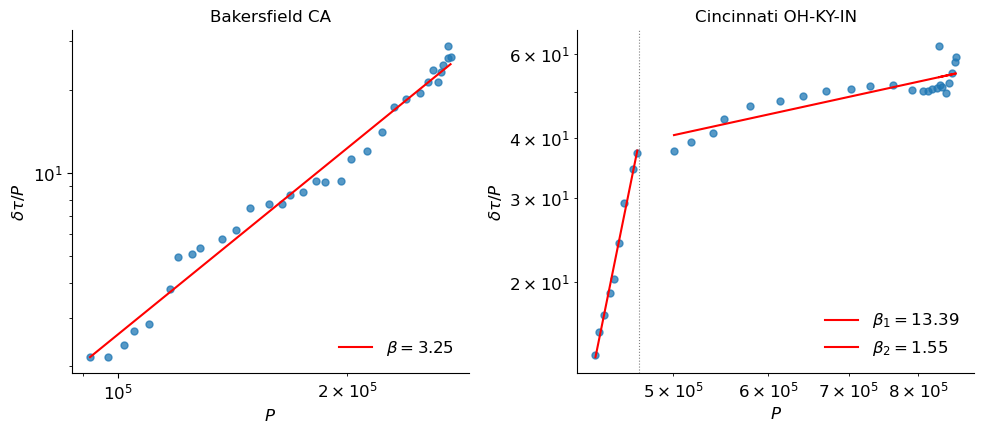

In [97]:
def plot_city(ax, name, kind):
    yrs, P, D, _ = city_panel(name)
    DP = D / P
    ax.semilogx(P, DP, "o", color="tab:blue", markersize=5, alpha=0.75)


    if kind == "type1":
        b, ia, _, _ = ols_loglog(P, D)
        # (Î´Ï„/P) ~ P^{Î²-1}
        xx = np.linspace(P.min(), P.max(), 80)
        ax.plot(xx, np.exp(ia) * xx**(b - 1), "r-", lw=1.5, label=fr"$\beta = {b:.2f}$")
        ax.legend(loc="lower right")
    elif kind == "type2":
        pw = best_piecewise(P, D, min_seg=5)
        k = pw["k"]
        x1, x2 = P[:k], P[k:]
        l1 = np.exp(pw["loga1"]) * x1**(pw["beta1"] - 1)
        l2 = np.exp(pw["loga2"]) * x2**(pw["beta2"] - 1)
        ax.plot(x1, l1, "r-", lw=1.5, label=fr"$\beta_1 = {pw['beta1']:.2f}$")
        ax.plot(x2, l2, "r-", lw=1.5, label=fr"$\beta_2 = {pw['beta2']:.2f}$")

        ax.axvline(pw["P_star"], color="grey", ls=":", lw=0.8)
        ax.legend(loc="lower right")

    ax.set_yscale("log")
    ax.set_xlabel(r"$P$")
    ax.set_ylabel(r"$\delta\tau / P$")
    ax.set_title(name)


fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
plot_city(axes[0], find_city("Bakersfield"), "type1")
plot_city(axes[1], find_city("Cincinnati"), "type2")
fig.tight_layout()
fig.savefig("figs/bakersfield_cincinnati.pdf", bbox_inches="tight", pad_inches=0)

## Fig. 6-7

In [98]:
results = {}
for c in cities_sorted:
    _, P, D, _ = city_panel(c)
    if len(P) < 10:
        continue
    b_s, _, r2_s, ss_s = ols_loglog(P, D)
    pw = best_piecewise(P, D, min_seg=5)
    dB = abs(pw["beta1"] - pw["beta2"])
    if r2_s >= 0.93 and dB <= 1.0:
        kind = "type1"
    elif dB >= 1.5 and pw["beta1"] > pw["beta2"]:
        kind = "type2"
    else:
        kind = "other"
    results[c] = dict(kind=kind, beta_single=b_s, r2_single=r2_s,
                      beta1=pw["beta1"], beta2=pw["beta2"],
                      P_star=pw["P_star"], k=pw["k"])

# Counts
counts = pd.Series([r["kind"] for r in results.values()]).value_counts()
print("\nCity-class counts:")
print(counts.to_string())

type1_betas = np.array([r["beta_single"] for r in results.values()
                        if r["kind"] == "type1"])
type2_b1 = np.array([r["beta1"] for r in results.values()
                     if r["kind"] == "type2"])
type2_b2 = np.array([r["beta2"] for r in results.values()
                     if r["kind"] == "type2"])


City-class counts:
type2    56
type1    23
other    22


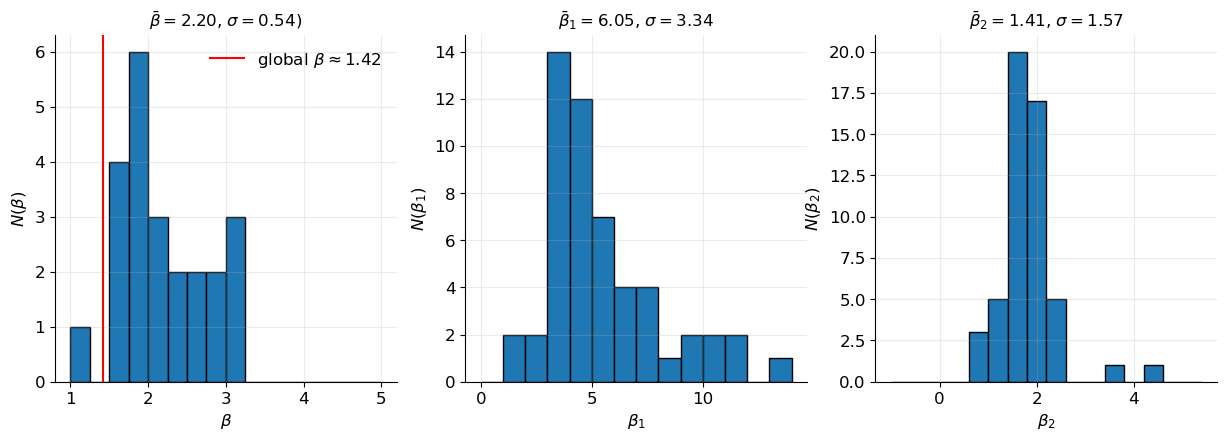

In [99]:
fig = plt.figure(figsize=(15, 4.5))

ax = fig.add_subplot(1,3,1)
ax.hist(type1_betas, bins=np.arange(1, 5.2, 0.25), edgecolor="k", color="tab:blue")
ax.axvline(beta_pool, color="red", lw=1.5, label=fr"global $\beta \approx {beta_pool:.2f}$")

ax.set_xlabel(r"$\beta$")
ax.set_ylabel(r"$N(\beta)$")
ax.set_title(fr"$\bar\beta = {type1_betas.mean():.2f}$, "
             fr"$\sigma = {type1_betas.std():.2f}$)")
ax.legend()
ax.grid(True, alpha=0.25)

# -------------------------

ax = fig.add_subplot(1,3,2)
ax.hist(type2_b1, bins=np.arange(0, 15, 1), edgecolor="k", color="tab:blue")
ax.set_xlabel(r"$\beta_1$")
ax.set_ylabel(r"$N(\beta_1)$")
ax.set_title(fr"$\bar\beta_1 = {type2_b1.mean():.2f}$, "
             fr"$\sigma = {type2_b1.std():.2f}$")
ax.grid(True, alpha=0.25)

# -------------------------

ax = fig.add_subplot(1,3,3)
ax.hist(type2_b2, bins=np.arange(-1, 5.5, 0.4), edgecolor="k", color="tab:blue")
ax.set_xlabel(r"$\beta_2$")
ax.set_ylabel(r"$N(\beta_2)$")
ax.set_title(fr"$\bar\beta_2 = {type2_b2.mean():.2f}$, "
            fr"$\sigma = {type2_b2.std():.2f}$")
ax.grid(True, alpha=0.25)
fig.savefig("figs/beta_beta_1_beta_2.pdf", bbox_inches="tight", pad_inches=0)

## Fig. 9

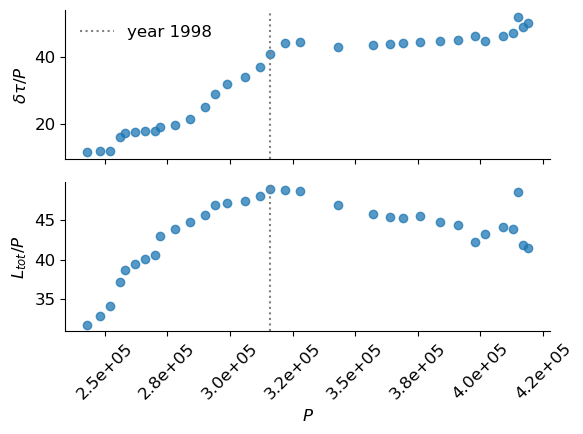

In [105]:
yrs, P, D, L = city_panel(find_city("Birmingham"))
DP = D / P
LP = L / P     # daily VMT per commuter (miles/driver/day)

# Locate change-point automatically (best piecewise on δτ/P scale)
pw = best_piecewise(P, D, n_outliers_per_seg=5)
# pw["k"] = 16
year_star = yrs[pw["k"]]

fig = plt.figure(figsize=(6, 4.5))
ax = fig.add_subplot(2,1,1)
ax.scatter(P, DP, color="tab:blue", s=36, alpha=0.75)
ax.axvline(P[pw["k"]], color="grey", ls=":", label=f"year {year_star}")

ax.set_ylabel(r"$\delta\tau / P$")
ax.legend()
ax.tick_params(axis='x', labelbottom=False)

ax = fig.add_subplot(2,1,2)
ax.scatter(P, LP, color="tab:blue", s=36, alpha=0.75)
ax.axvline(P[pw["k"]], color="grey", ls=":")

ax.set_xlabel(r"$P$")
ax.set_ylabel(r"$L_{tot}/P$")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.01e}"))
ax.tick_params(axis='x', rotation=45)
fig.tight_layout()
fig.savefig("figs/birmingham.pdf", bbox_inches="tight", pad_inches=0)